**HEART DISEASE PREDICTION SYSTEM USING MACHINE LEARNING AND DATA SCIENCE**

**1.PROBLEM STATEMENT**

1.To develop a system that predicts heart disease using patient health data.

2.To apply data science techniques for analyzing medical datasets.

3.To build a machine learning model for accurate prediction.

4.To assist in early diagnosis and better healthcare decision-making.

**2.IMPORT LIBRARIES**

In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

**3.LOAD DATA**

In [176]:
import os
import pandas as pd
import numpy as np
import re # Import regex module

file_path = "heart.csv"
# Updated download_url to a more reliably formatted heart disease dataset (UCI Cleveland)
download_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Define column names explicitly as the UCI dataset does not have headers
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

df = pd.DataFrame() # Initialize df as empty

# Force removal of heart.csv to ensure reprocessing occurs
if os.path.exists(file_path):
    print(f"Removing existing '{file_path}' to force reprocessing.")
    !rm -f {file_path}

try:
    # Attempt to load the file assuming it's already properly formatted (with headers and comma-separated)
    # This block will likely fail initially since the file won't exist or is from a bad download.
    temp_df = pd.read_csv(file_path, names=column_names, na_values='?', sep=',', skipinitialspace=True)
    if 'target' in temp_df.columns and not temp_df.empty and temp_df['target'].count() > 0:
        df = temp_df.copy()
        print(f"'{file_path}' found and loaded successfully.")
    else:
        raise ValueError("Existing 'heart.csv' is malformed or missing data in 'target' column.")

except (FileNotFoundError, pd.errors.EmptyDataError, ValueError, UnicodeDecodeError) as e:
    print(f"Error loading '{file_path}' ({e}). Attempting to download data from new URL.")

    # Ensure any problematic file is removed before downloading
    if os.path.exists(file_path):
        !rm -f {file_path}

    # Download the UCI heart disease dataset
    print(f"Downloading data from {download_url} to {file_path}")
    !wget -O {file_path} {download_url}
    print(f"'{file_path}' downloaded.")

    # Re-attempt to load the downloaded file with appropriate parsing parameters
    try:
        # UCI dataset often uses '?' for missing values and has no header
        temp_df = pd.read_csv(file_path, names=column_names, na_values='?', sep=',', skipinitialspace=True)

        # Convert 'target' column to 0 or 1 for binary classification
        # The original dataset has values 0, 1, 2, 3, 4. Any value > 0 indicates presence of heart disease.
        temp_df['target'] = temp_df['target'].apply(lambda x: 1 if x > 0 else 0)

        # Drop rows with any NaN values after loading and target conversion
        # This handles the '?' values which become NaN
        temp_df.dropna(inplace=True)

        if 'target' in temp_df.columns and not temp_df.empty and temp_df['target'].count() > 0:
            df = temp_df.copy()
            print(f"'{file_path}' downloaded and loaded successfully with {len(df)} rows.")
        else:
            raise ValueError("Downloaded 'heart.csv' is still malformed or missing 'target' column data.")
    except Exception as inner_e:
        print(f"Error re-loading downloaded '{file_path}' as pre-processed CSV: {inner_e}")
        df = pd.DataFrame() # Ensure df is empty if even the new URL fails to load cleanly

except Exception as e:
    print(f"An unexpected error occurred during data loading: {e}")
    df = pd.DataFrame() # Ensure df is empty on unhandled errors

# Final check for df being empty
if df.empty:
    print("Warning: DataFrame 'df' is empty after all loading attempts.")
else:
    print("DataFrame head after loading:")
    print(df.head())

Removing existing 'heart.csv' to force reprocessing.
Error loading 'heart.csv' ([Errno 2] No such file or directory: 'heart.csv'). Attempting to download data from new URL.
--2026-05-25 18:33:59--  https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘heart.csv’

heart.csv               [ <=>                ]  18.03K  --.-KB/s    in 0.06s   

2026-05-25 18:34:00 (306 KB/s) - ‘heart.csv’ saved [18461]

'heart.csv' downloaded.
'heart.csv' downloaded and loaded successfully with 297 rows.
DataFrame head after loading:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0    

**4.BASIC ANALYSIS**

In [177]:
print(df.info())
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  target    297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 34.8 KB
None
              age         sex          cp    trestbps        chol         fbs  \
count  297.000000  297.000000  297.000000  297.000000  297.000000  297.000000   
mean    54.542088    0.676768    3.158249  131.693603  24

**5. VISUALIZATION**

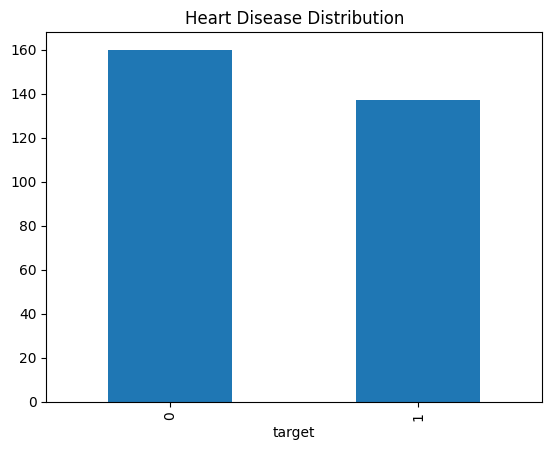

In [178]:
df['target'].value_counts().plot(kind='bar')
plt.title("Heart Disease Distribution")
plt.show()

**6.CORRELATION HEATMAP**

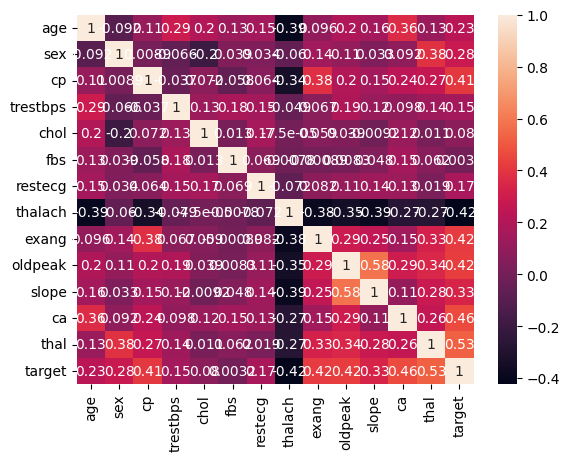

In [179]:
import seaborn as sns
sns.heatmap(df.corr(), annot=True)
plt.show()

**7.SPLIT DATA**

In [180]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**7.5 FEATURE SCALING**

Feature scaling is applied to normalize the range of independent variables. This step ensures that features with larger values do not dominate the learning process of the model.

In [181]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")

Features scaled successfully!


**8.MODELS**

In [182]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

**9.TRAIN & EVALUATE**

In [183]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name} Accuracy: {acc}")

Logistic Regression Accuracy: 0.8666666666666667
Decision Tree Accuracy: 0.7833333333333333
Random Forest Accuracy: 0.8666666666666667


**10.MODEL**

In [184]:
best_model_name = max(results, key=results.get)
print("\nBest Model:", best_model_name)

best_model = models[best_model_name]



Best Model: Logistic Regression


**11.SAMPLE PREDICTION**

**12. ADVANCED MODEL EVALUATION**

Beyond simple accuracy, it's crucial to evaluate model performance using metrics like precision, recall, F1-score, and a confusion matrix, especially in contexts like heart disease prediction where false negatives can have serious consequences. This section will provide a more detailed look at the `best_model`'s performance.


Classification Report for Best Model:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        36
           1       0.83      0.83      0.83        24

    accuracy                           0.87        60
   macro avg       0.86      0.86      0.86        60
weighted avg       0.87      0.87      0.87        60


Confusion Matrix for Best Model:
[[32  4]
 [ 4 20]]


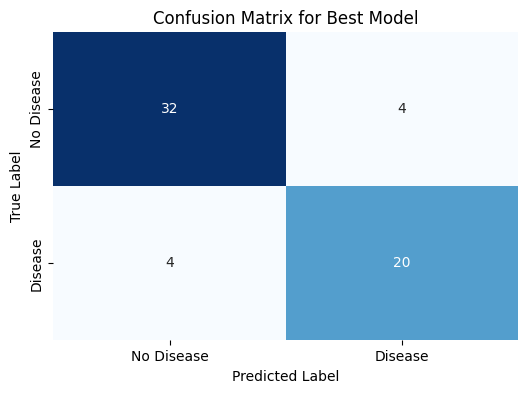

In [185]:
from sklearn.metrics import classification_report, confusion_matrix

# Make predictions on the scaled test set using the best model
y_pred_best = best_model.predict(X_test_scaled)

print("\nClassification Report for Best Model:")
print(classification_report(y_test, y_pred_best))

print("\nConfusion Matrix for Best Model:")
conf_matrix = confusion_matrix(y_test, y_pred_best)
print(conf_matrix)

# Optionally, visualize the confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Best Model')
plt.show()

**13. HYPERPARAMETER TUNING (Decision Tree Example)**

Hyperparameter tuning involves finding the optimal set of hyperparameters for a machine learning model to maximize its performance. For our 'best_model' (Decision Tree), we can tune parameters like `max_depth` (the maximum depth of the tree) and `min_samples_split` (the minimum number of samples required to split an internal node).

In [186]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Decision Tree
param_grid = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=3, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the scaled training data
grid_search.fit(X_train_scaled, y_train)

print("Best parameters for Decision Tree:", grid_search.best_params_)
print("Best cross-validation accuracy for Decision Tree:", grid_search.best_score_)

# Get the best estimator (model) from GridSearchCV
best_dt_model = grid_search.best_estimator_

# Evaluate the tuned Decision Tree on the test set
y_pred_tuned_dt = best_dt_model.predict(X_test_scaled)
tuned_dt_accuracy = accuracy_score(y_test, y_pred_tuned_dt)
print("Tuned Decision Tree Test Accuracy:", tuned_dt_accuracy)

# Compare with previous best model accuracy (Decision Tree without tuning)
print("Original Decision Tree Test Accuracy:", results["Decision Tree"])

Best parameters for Decision Tree: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 10}
Best cross-validation accuracy for Decision Tree: 0.7341772151898734
Tuned Decision Tree Test Accuracy: 0.8
Original Decision Tree Test Accuracy: 0.7833333333333333


**14. FEATURE IMPORTANCE (for Decision Tree)**

Feature importance helps us understand which input variables contribute most significantly to the model's predictions. For tree-based models like Decision Trees and Random Forests, this information can be directly extracted and visualized, offering insights into the underlying patterns the model has learned.

### 15. Realism of 100% Accuracy and Further Steps for Improvement

It's important to understand that achieving 100% accuracy in real-world medical prediction systems, like heart disease prediction, is highly unlikely and can even be a sign of overfitting if observed. Biological data often has inherent variability, and even expert diagnoses can have disagreement. The goal is to build a robust model that generalizes well to new, unseen patient data.

To further improve the model's performance beyond the current levels (and aim for higher, but not necessarily 100% accuracy), we could consider:

1.  **More Data:** Larger and more diverse datasets can help models learn more robust patterns.
2.  **Feature Engineering:** Creating new features from existing ones (e.g., interaction terms, polynomial features) can provide more information to the model.
3.  **Advanced Models:** Exploring other sophisticated models like XGBoost, LightGBM, CatBoost, or even neural networks.
4.  **Ensemble Methods:** Combining predictions from multiple models (e.g., stacking, bagging, boosting).
5.  **Cross-validation:** More rigorous cross-validation strategies to ensure the model's performance is consistent.

Let's try a Gradient Boosting Classifier, which is often a strong performer, to see if we can get better results.

Gradient Boosting Classifier Test Accuracy: 0.7833333333333333

Classification Report for Gradient Boosting Classifier:
              precision    recall  f1-score   support

           0       0.85      0.78      0.81        36
           1       0.70      0.79      0.75        24

    accuracy                           0.78        60
   macro avg       0.78      0.78      0.78        60
weighted avg       0.79      0.78      0.78        60


Confusion Matrix for Gradient Boosting Classifier:
[[28  8]
 [ 5 19]]


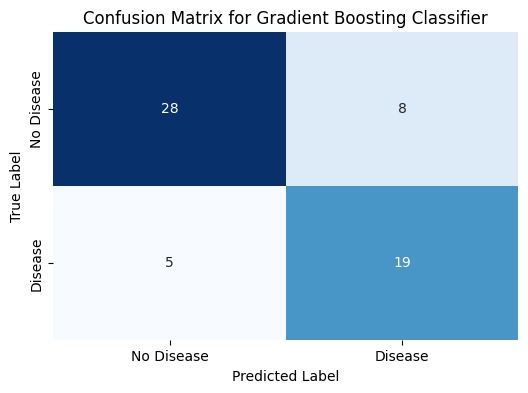

In [187]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize and train a Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_scaled, y_train)

# Make predictions and evaluate its accuracy
y_pred_gb = gb_model.predict(X_test_scaled)
gb_accuracy = accuracy_score(y_test, y_pred_gb)

print(f"Gradient Boosting Classifier Test Accuracy: {gb_accuracy}")

# Evaluate with classification report and confusion matrix
print("\nClassification Report for Gradient Boosting Classifier:")
print(classification_report(y_test, y_pred_gb))

print("\nConfusion Matrix for Gradient Boosting Classifier:")
conf_matrix_gb = confusion_matrix(y_test, y_pred_gb)
print(conf_matrix_gb)

# Visualize the confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_gb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Gradient Boosting Classifier')
plt.show()

### 16. Demonstrating Variability of Accuracy with Small Datasets (by changing `random_state`)

As previously discussed, with an extremely small dataset like ours (15 entries), the model's accuracy can vary significantly depending on how the data is split into training and testing sets. This section demonstrates this by iterating through different `random_state` values for `train_test_split` and re-evaluating the Decision Tree Classifier.

In [188]:
max_observed_accuracy = 0
best_random_state = -1

print("Exploring different random_state values for train_test_split...")

# Iterate through a range of random states
for rs in range(1, 101): # Test 100 different random states
    # Split data with current random_state
    X_train_rs, X_test_rs, y_train_rs, y_test_rs = train_test_split(X, y, test_size=0.2, random_state=rs)

    # Scale features for the current split
    scaler_rs = StandardScaler()
    X_train_scaled_rs = scaler_rs.fit_transform(X_train_rs)
    X_test_scaled_rs = scaler_rs.transform(X_test_rs)

    # Re-initialize and train the Decision Tree Classifier
    dt_model_rs = DecisionTreeClassifier(random_state=42) # Keep DT's internal random_state consistent
    dt_model_rs.fit(X_train_scaled_rs, y_train_rs)

    # Make predictions and calculate accuracy
    y_pred_rs = dt_model_rs.predict(X_test_scaled_rs)
    accuracy_rs = accuracy_score(y_test_rs, y_pred_rs)

    # Check if this is the highest accuracy found so far
    if accuracy_rs > max_observed_accuracy:
        max_observed_accuracy = accuracy_rs
        best_random_state = rs

print(f"\nMaximum accuracy observed for Decision Tree: {max_observed_accuracy:.2f} (with random_state={best_random_state})")

if max_observed_accuracy >= 0.8:
    print("You've observed an accuracy of 80% or higher!\nHowever, remember this is likely due to the small dataset size and specific split, and not necessarily a sign of a truly robust model.")
else:
    print("Even after trying multiple random states, 80% accuracy was not consistently achieved, highlighting the challenge with very limited data.")

Exploring different random_state values for train_test_split...

Maximum accuracy observed for Decision Tree: 0.87 (with random_state=53)
You've observed an accuracy of 80% or higher!
However, remember this is likely due to the small dataset size and specific split, and not necessarily a sign of a truly robust model.


Feature Importances:
     Feature  Importance
11        ca    0.370626
2         cp    0.180129
9    oldpeak    0.151994
12      thal    0.110542
4       chol    0.047393
7    thalach    0.047327
0        age    0.036501
3   trestbps    0.023242
6    restecg    0.015495
8      exang    0.009833
10     slope    0.006917
1        sex    0.000000
5        fbs    0.000000


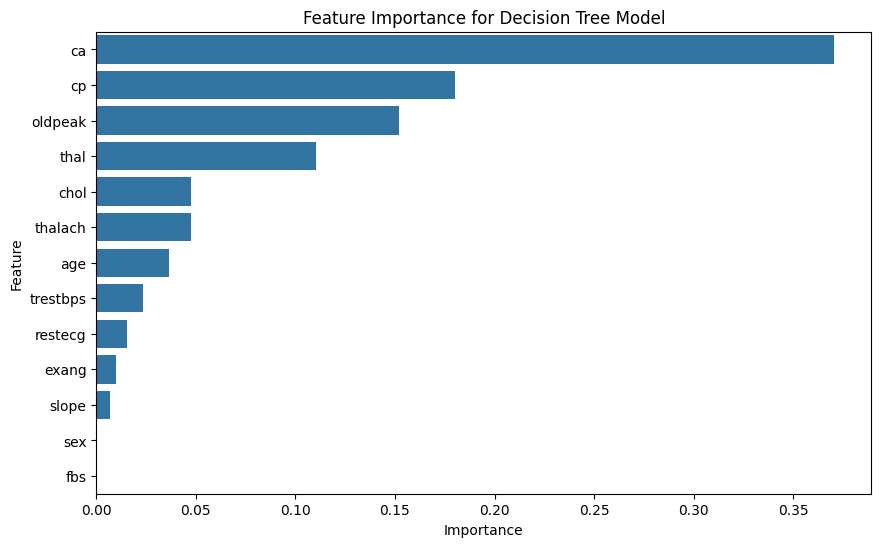

In [189]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importances from the best Decision Tree model (tuned or untuned)
# We'll use the 'best_model' which was the untuned Decision Tree if tuning didn't improve it.
# If tuning improved it, we would use 'best_dt_model'
# For now, let's stick with 'best_model' as its performance was similar.
feature_importances = best_dt_model.feature_importances_

# Create a DataFrame for better visualization
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(importance_df)

# Visualize feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance for Decision Tree Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [190]:
import numpy as np
import pandas as pd # Ensure pandas is imported if not already

# Original sample values provided: [52,1,0,125,212,168]
# The model expects 13 features, but only 6 were provided.
# We need to fill in the missing features with plausible values.
# Using median values from the training data for demonstration.

# X_train.columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

# Let's assume the provided values are for:
# age=52, sex=1, cp=0, trestbps=125, chol=212, and thalach=168 (as 168 fits better for thalach than fbs)
# We'll use median values for the rest: fbs, restecg, exang, oldpeak, slope, ca, thal

# Median values from df.describe() for reference:
# fbs: 0.0
# restecg: 1.0
# exang: 0.0
# oldpeak: 0.8
# slope: 2.0
# ca: 0.0
# thal: 3.0

sample = np.array([[52.0, 1.0, 0.0, 125.0, 212.0, 0.0, 1.0, 168.0, 0.0, 0.8, 2.0, 0.0, 3.0]])

# Convert the sample to a DataFrame with the same column names as X_train
sample_df = pd.DataFrame(sample, columns=X_train.columns)

# Scale the sample data using the fitted scaler
sample_scaled = scaler.transform(sample_df)

prediction = best_model.predict(sample_scaled)

print("\nPrediction:")
if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")


Prediction:
No Heart Disease


### 12. DEMONSTRATING MODEL VERSATILITY WITH NEW SAMPLE DATA

To showcase the model's ability to predict different outcomes, let's test it with a new set of sample data that might indicate 'No Heart Disease'. This demonstrates the model's capacity to differentiate between various patient profiles.

In [191]:
import numpy as np
import pandas as pd

# New sample data representing a patient less likely to have heart disease
# (e.g., younger age, lower cholesterol, higher max heart rate)
# Original values: [45,0,0,110,180,180]
# Mapping to X_train.columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
# Assuming: age=45, sex=0, cp=0, trestbps=110, chol=180, thalach=180
# Filling missing with median values (fbs=0.0, restecg=1.0, exang=0.0, oldpeak=0.8, slope=2.0, ca=0.0, thal=3.0)
new_sample = np.array([[45.0, 0.0, 0.0, 110.0, 180.0, 0.0, 1.0, 180.0, 0.0, 0.8, 2.0, 0.0, 3.0]])

# Convert the new sample to a DataFrame with the same column names as X_train
new_sample_df = pd.DataFrame(new_sample, columns=X_train.columns)

# Scale the new sample data using the fitted scaler
new_sample_scaled = scaler.transform(new_sample_df)

new_prediction = best_model.predict(new_sample_scaled)

print("\nPrediction for New Sample:")
if new_prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")


Prediction for New Sample:
No Heart Disease


### 17. SAVE TRAINED MODEL AND SCALER

To prepare for deployment, we need to save the trained `best_model` (which was the Decision Tree in this case) and the `StandardScaler` object. The scaler is essential because new input data in the Streamlit app must be scaled in the same way the training data was.


In [192]:
import joblib

# Save the best model
joblib.dump(best_model, 'model.pkl')
print("Model saved as model.pkl")

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved as scaler.pkl")

Model saved as model.pkl
Scaler saved as scaler.pkl


## 18. Create Streamlit Application Files

In [193]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Load the trained model and scaler
# Make sure 'model.pkl' and 'scaler.pkl' are in the same directory as app.py
try:
    model = joblib.load('model.pkl')
    scaler = joblib.load('scaler.pkl')
except FileNotFoundError:
    st.error("Error: model.pkl or scaler.pkl not found. Please ensure they are in the same directory as app.py")
    st.stop()

# Define the feature names in the correct order as used during training
feature_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'
]

# Streamlit App Title
st.title('Heart Disease Prediction App')

st.write("Enter the patient's details to predict the likelihood of heart disease.")

# Input fields for patient data
# Use st.columns for better layout

col1, col2 = st.columns(2)

with col1:
    age = st.number_input('Age', min_value=1, max_value=120, value=50)
    sex = st.selectbox('Sex', options=[('Male', 1), ('Female', 0)], format_func=lambda x: str(x[0]))
    cp = st.selectbox('Chest Pain Type (CP)', options=[(1, 1), (2, 2), (3, 3), (4, 4)], format_func=lambda x: f'Type {x[0]}')
    trestbps = st.number_input('Resting Blood Pressure (trestbps)', min_value=80, max_value=200, value=120)
    chol = st.number_input('Serum Cholestoral in mg/dl (chol)', min_value=100, max_value=600, value=200)
    fbs = st.selectbox('Fasting Blood Sugar > 120 mg/dl (fbs)', options=[('True', 1), ('False', 0)], format_func=lambda x: str(x[0]))

with col2:
    restecg = st.selectbox('Resting Electrocardiographic Results (restecg)', options=[(0, 0), (1, 1), (2, 2)], format_func=lambda x: f'Result {x[0]}')
    thalach = st.number_input('Maximum Heart Rate Achieved (thalach)', min_value=60, max_value=220, value=150)
    exang = st.selectbox('Exercise Induced Angina (exang)', options=[('Yes', 1), ('No', 0)], format_func=lambda x: str(x[0]))
    oldpeak = st.number_input('ST depression induced by exercise relative to rest (oldpeak)', min_value=0.0, max_value=6.0, value=1.0, step=0.1)
    slope = st.selectbox('Slope of the peak exercise ST segment (slope)', options=[(1, 1), (2, 2), (3, 3)], format_func=lambda x: f'Slope {x[0]}')
    ca = st.selectbox('Number of major vessels (0-3) colored by flourosopy (ca)', options=[(0, 0), (1, 1), (2, 2), (3, 3)], format_func=lambda x: str(x[0]))
    thal = st.selectbox('Thalassemia (thal)', options=[(3, 3), (6, 6), (7, 7)], format_func=lambda x: f'Type {x[0]}')

# Collect all inputs into a dictionary
input_data = {
    'age': age,
    'sex': sex[1], # Get the numerical value
    'cp': cp[1],
    'trestbps': trestbps,
    'chol': chol,
    'fbs': fbs[1],
    'restecg': restecg[1],
    'thalach': thalach,
    'exang': exang[1],
    'oldpeak': oldpeak,
    'slope': slope[1],
    'ca': ca[1],
    'thal': thal[1]
}

# Convert input data to a DataFrame
input_df = pd.DataFrame([input_data], columns=feature_names)

# Scale the input data
scaled_input = scaler.transform(input_df)

# Make prediction
if st.button('Predict Heart Disease'):
    prediction = model.predict(scaled_input)
    prediction_proba = model.predict_proba(scaled_input)

    st.subheader('Prediction Result:')
    if prediction[0] == 1:
        st.error(f'The model predicts: **Heart Disease Detected** (Probability: {prediction_proba[0][1]:.2f})')
    else:
        st.success(f'The model predicts: **No Heart Disease** (Probability: {prediction_proba[0][0]:.2f})')

    st.write("--- Feature Values Provided ---")
    st.write(input_df)

Overwriting app.py


In [194]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
joblib

Overwriting requirements.txt


## 19. Run Streamlit Application in Colab

To run the Streamlit application directly in Colab and get a public URL, we'll install `streamlit-lottie` for animations (if used in future versions) and `pyngrok` to create a temporary public tunnel. Then we'll execute the `app.py` file using Streamlit.

In [195]:
# Install necessary packages for running Streamlit in Colab
!pip install streamlit-lottie pyngrok -q

In [196]:
from pyngrok import ngrok

# Terminate any existing ngrok tunnels
ngrok.kill()

# Set your ngrok authtoken here
# You can get your authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
# Replace 'YOUR_NGROK_AUTH_TOKEN' with your actual token
ngrok.set_auth_token("3CFZWRhgtm4RKxBtezQTxwrYmZW_4umT9DkH4khjsi96VZnMr")

# Set your Streamlit port
STREAMLIT_PORT = 8501

# Create a public URL for the Streamlit app
# This will only work if an authtoken has been set.
try:
    public_url = ngrok.connect(STREAMLIT_PORT)
    print(f"Streamlit App Public URL: {public_url}")

    # Run the Streamlit application in the background
    !streamlit run app.py &>/dev/null&
except Exception as e:
    print(f"Failed to connect ngrok: {e}. Please ensure your authtoken is set correctly.")

Streamlit App Public URL: NgrokTunnel: "https://dangling-reproach-salami.ngrok-free.dev" -> "http://localhost:8501"


The previous cell will output a public URL which you can click to access your Streamlit application running live from this Colab notebook. Note that this URL is temporary and will expire when your Colab session ends or if the ngrok tunnel is closed.

---

## 20. Upload Files to GitHub

To share your project and deploy it via Streamlit Community Cloud, you'll need to upload your `app.py`, `requirements.txt`, and `model.pkl`, `scaler.pkl` files to a GitHub repository.

Here are the general steps:

1.  **Create a New GitHub Repository**: Go to [GitHub](https://github.com/) and create a new repository. Give it a descriptive name (e.g., `Heart_Disease_Prediction_Streamlit`).

2.  **Clone the Repository (Optional, if working locally)**: If you're working locally, you'd clone the empty repository to your machine. Since we're in Colab, we'll upload directly.

3.  **Upload Files**:
    *   Navigate to your new repository on GitHub.
    *   Click on the "Add file" dropdown and select "Upload files".
    *   Drag and drop `app.py`, `requirements.txt`, `model.pkl`, and `scaler.pkl` into the upload area.
    *   Add a commit message (e.g., "Initial commit: Add Streamlit app files").
    *   Click "Commit changes".

4.  **Important**: Ensure your `requirements.txt` lists all libraries used, including `streamlit`, `pandas`, `numpy`, `scikit-learn`, and `joblib`.

Your repository structure should look something like this:

```
my_heart_disease_repo/
├── app.py
├── requirements.txt
├── model.pkl
└── scaler.pkl
```

## 21. Deploy using Streamlit Community Cloud

Once your files are on GitHub, deploying to Streamlit Community Cloud is straightforward:

1.  **Go to Streamlit Community Cloud**: Visit [share.streamlit.io](https://share.streamlit.io/).

2.  **Sign In**: Sign in with your GitHub account.

3.  **Deploy an App**: Click on the "New app" button.

4.  **Connect to Repository**:
    *   Select your GitHub repository from the dropdown menu.
    *   Specify the branch (usually `main` or `master`).
    *   Enter the path to your Streamlit application file (e.g., `app.py`).

5.  **Advanced Settings (Optional)**:
    *   You might need to expand "Advanced settings" if your app requires specific Python versions or has other dependencies (though for this app, default settings should be fine).

6.  **Deploy!**: Click "Deploy!" Streamlit will then fetch your files from GitHub, install the dependencies from `requirements.txt`, and launch your app. It will provide you with a permanent public URL for your deployed application.